In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv(r"C:\Users\anhki\OneDrive\Desktop\creditcard (1).csv")
print(data.head())
print(data["Class"].value_counts())  # xem tỉ lệ giữa Fraud và Non-Fraud

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
X = data.drop("Class", axis=1)
y = data["Class"]


In [ ]:
# Chia dữ liệu Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Feature Engineering
# Mục tiêu: giúp logistic học mối quan hệ phi tuyến
X_train['Amount_log'] = np.log1p(X_train['Amount'])
X_test['Amount_log'] = np.log1p(X_test['Amount'])

# Có thể thêm tương tác (nếu có biến số kiểu V1, V2,...)
if 'V1' in X_train.columns and 'V2' in X_train.columns:
    X_train['V1_V2'] = X_train['V1'] * X_train['V2']
    X_test['V1_V2'] = X_test['V1'] * X_test['V2']

In [ ]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Huấn luyện Logistic Regression
model = LogisticRegression(
    solver='liblinear',     # phù hợp cho dữ liệu nhị phân
    penalty='l2',           # regularization chuẩn
    C=1.0,                  # mức regularization (có thể thử 0.5, 2.0)
    random_state=42,
    max_iter=2000
)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')

In [ ]:
#bDự đoán xác suất
y_score = model.predict_proba(X_test_scaled)[:, 1]

# Chọn ngưỡng dự đoán
threshold = 0.6 
y_pred = (y_score >= threshold).astype(int)



=== Báo cáo phân loại (Logistic Regression cải thiện) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



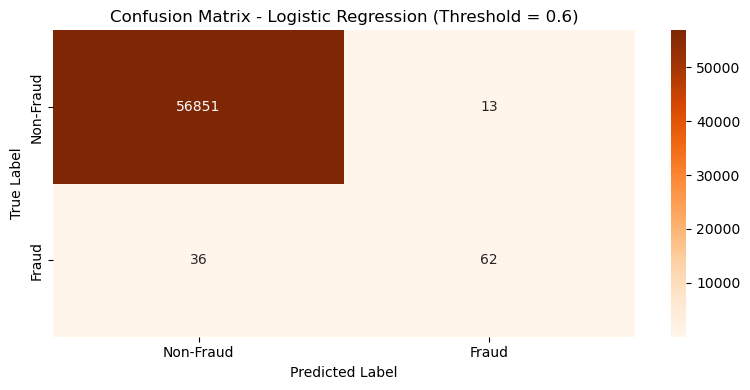

ROC AUC Score: 0.9596


In [ ]:
# Đánh giá mô hình
print("\n=== Báo cáo phân loại (Logistic Regression cải thiện) ===")
print(classification_report(y_test, y_pred, digits=2))

cm = confusion_matrix(y_test, y_pred)
labels = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(8,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - Logistic Regression (Threshold = {threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

roc = roc_auc_score(y_test, y_score)
print(f"ROC AUC Score: {roc:.4f}")

